# Accident verifier: CLIP linear probe

### Why a linear probe rather than fine-tuning a CNN

A frozen CLIP encoder plus a logistic-regression head needs a couple of hundred labelled
images instead of tens of thousands, trains in under a minute on CPU, and is far more robust
to the domain shift we cannot avoid public accident datasets are mostly dashcam or CCTV
footage of the *moment of impact*, while our real input is a handheld phone photo of the
*aftermath*. Fine-tuning a ResNet on the wrong distribution would overfit to that gap; a
frozen general-purpose encoder degrades more gracefully.

In [1]:
%pip install -q roboflow

import json, random
from collections import Counter
from pathlib import Path

from PIL import Image

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device', DEVICE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.0 MB/s eta 0:00:00
torch 2.11.0+cu128 | device cuda


In [ ]:
ROBOFLOW_API_KEY = ''       

WORKSPACE = 'sathwik-suresh-shetty'
PROJECT   = 'vehicle-accident-detection-1vdk8-gs41n'
VERSION   = 1
FORMAT    = 'folder'         


NEGATIVE_SOURCES = [
    {'workspace': 'sathwik-suresh-shetty', 'project': 'cars-vsirj-sa58r', 'version': 1},
]


NEGATIVE_FOLDERS = [
    # 'data/my_photos/normal',
]


MAIN_LABEL = 1


EXCLUDE_SOURCES = [
    'Unlabeled', 'images',      
]

SOURCE_OVERRIDES = {
    # 'minor_scratch': 0,
}


REALITY_CHECK_DIR = 'data/reality_check'

CLIP_MODEL = 'openai/clip-vit-base-patch32'   
BATCH_SIZE = 64


NEGATIVE_KEYWORDS = ('non accident', 'no accident', 'not accident', 'no crash',
                     'no damage', 'undamaged', 'intact', 'whole',
                     'normal', 'safe', 'traffic', 'background', 'none')
POSITIVE_KEYWORDS = ('accident', 'crash', 'collision', 'wreck', 'wrecked',
                     'damage', 'damaged', 'overturn', 'rollover',
                     'severe', 'moderate', 'minor')


TARGET_RECALL = 0.95

ARTIFACTS = Path('artifacts')
ARTIFACTS.mkdir(exist_ok=True)

assert ROBOFLOW_API_KEY, 'Set ROBOFLOW_API_KEY first'
assert WORKSPACE and PROJECT, 'Set WORKSPACE and PROJECT first'

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

def fetch(workspace, project, version, fmt, location):
    if Path(location).exists():
        print('already downloaded ->', location)
        return Path(location)

    handle = rf.workspace(workspace).project(project).version(version)
    result = handle.download(fmt, location=location)
    return Path(result.location)

main_dir = fetch(WORKSPACE, PROJECT, VERSION, FORMAT, 'data/main')
print('main dataset ->', main_dir)

negative_dirs = []
for n, source in enumerate(NEGATIVE_SOURCES):
    location = f'data/negatives_{n}'
    negative_dirs.append(fetch(source.get('workspace') or WORKSPACE, source['project'],
                               source.get('version', 1),
                               source.get('format', 'folder'), location))
    print('negatives ->', negative_dirs[-1])

if not NEGATIVE_SOURCES and not NEGATIVE_FOLDERS:
    print('no negative sources configured - section 4 will tell you if that is a problem')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/main in folder:: 100%|██████████| 7447/7447 [00:02<00:00, 3566.66it/s]


main dataset -> /content/data/main
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/negatives_0 in folder:: 100%|██████████| 3849/3849 [00:01<00:00, 3360.10it/s]

negatives -> /content/data/negatives_0


In [ ]:
IMAGE_SUFFIXES = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def is_positive_class(name):
    normalized = name.lower().replace('_', ' ').replace('-', ' ')

    if any(word in normalized for word in NEGATIVE_KEYWORDS):
        return False

    return any(word in normalized for word in POSITIVE_KEYWORDS)

def index_folder_dataset(root, force_label=None, dataset='main'):
    rows = []
    for split_dir in sorted(Path(root).iterdir()):
        if not split_dir.is_dir():
            continue
        split = split_dir.name.lower()
        if split not in {'train', 'valid', 'val', 'test'}:
            continue
        split = 'valid' if split == 'val' else split

        for class_dir in sorted(split_dir.iterdir()):
            if not class_dir.is_dir():
                continue
            label = force_label if force_label is not None else int(is_positive_class(class_dir.name))
            for path in sorted(class_dir.rglob('*')):
                if path.suffix.lower() in IMAGE_SUFFIXES:
                    rows.append({'path': str(path), 'label': label, 'split': split,
                                 'source': class_dir.name, 'dataset': dataset})
    return rows

def index_yolo_dataset(root, dataset='main'):
    rows = []
    for split_dir in sorted(Path(root).iterdir()):
        if not split_dir.is_dir():
            continue
        split = split_dir.name.lower()
        if split not in {'train', 'valid', 'val', 'test'}:
            continue
        split = 'valid' if split == 'val' else split

        images = split_dir / 'images'
        labels = split_dir / 'labels'
        if not images.is_dir():
            continue

        for path in sorted(images.iterdir()):
            if path.suffix.lower() not in IMAGE_SUFFIXES:
                continue
            label_file = labels / (path.stem + '.txt')
            has_box = label_file.exists() and label_file.read_text().strip() != ''
            rows.append({'path': str(path), 'label': int(has_box), 'split': split,
                         'source': 'boxed' if has_box else 'background', 'dataset': dataset})
    return rows

def index_loose_folder(root, label, source, dataset=None):
    """Any directory of images. Split is assigned later."""
    rows = []
    for path in sorted(Path(root).rglob('*')):
        if path.suffix.lower() in IMAGE_SUFFIXES:
            rows.append({'path': str(path), 'label': label, 'split': None,
                         'source': source, 'dataset': dataset or source})
    return rows

rows = (index_folder_dataset(main_dir, force_label=MAIN_LABEL, dataset=f'main:{PROJECT}')
        if FORMAT == 'folder'
        else index_yolo_dataset(main_dir, dataset=f'main:{PROJECT}'))

if MAIN_LABEL is not None:
    print(f'main dataset forced to label {MAIN_LABEL} '
          f"({'accident' if MAIN_LABEL else 'not accident'}), folder names ignored")

for n, directory in enumerate(negative_dirs):
    fmt = NEGATIVE_SOURCES[n].get('format', 'folder')
    tag = f"negatives_{n}:{NEGATIVE_SOURCES[n]['project']}"
    if fmt == 'folder':
        found = index_folder_dataset(directory, force_label=0, dataset=tag)
        if not found:                      # flat export with no split folders
            found = index_loose_folder(directory, 0, f'negatives_{n}', dataset=tag)
    else:
        found = [dict(r, label=0, source=f'negatives_{n}')
                 for r in index_yolo_dataset(directory, dataset=tag)]
    print(f'  negatives_{n}: {len(found)} images')
    rows += found

for directory in NEGATIVE_FOLDERS:
    found = index_loose_folder(directory, 0, f'local:{Path(directory).name}',
                               dataset=f'local:{Path(directory).name}')
    print(f'  {directory}: {len(found)} images')
    rows += found


EXCLUDE_LOWER = {name.lower() for name in EXCLUDE_SOURCES}
OVERRIDES_LOWER = {k.lower(): v for k, v in SOURCE_OVERRIDES.items()}

if EXCLUDE_LOWER:
    before = len(rows)
    rows = [r for r in rows if r['source'].lower() not in EXCLUDE_LOWER]
    print(f'excluded {before - len(rows)} images from {sorted(EXCLUDE_LOWER)}')

if OVERRIDES_LOWER:
    changed = 0
    for row in rows:
        forced = OVERRIDES_LOWER.get(row['source'].lower())
        if forced is not None and row['label'] != forced:
            row['label'] = forced
            changed += 1
    print(f'relabelled {changed} images via SOURCE_OVERRIDES')

unassigned = [r for r in rows if r['split'] is None]
if unassigned:
    random.Random(SEED).shuffle(unassigned)
    for n, row in enumerate(unassigned):
        row['split'] = 'train' if n % 5 < 3 else ('valid' if n % 5 == 3 else 'test')
    print(f'assigned a split to {len(unassigned)} loose images (60/20/20)')


numeric_sources = sorted({r['source'] for r in rows
                          if r['source'].replace(' ', '').isdigit()})
if numeric_sources:
    print()
    print('NOTE: these folders are named with bare numbers:', numeric_sources[:12])
    print('      They are probably class ids from a detection dataset rather than')
    print('      categories. Check the sample grid below before trusting the labels,')
    print('      and use EXCLUDE_SOURCES or SOURCE_OVERRIDES if they are wrong.')
    print()

print('images indexed:', len(rows))
print('by split      :', Counter(r['split'] for r in rows))
print('by label      :', Counter(r['label'] for r in rows), '  (1 = accident)')
print()
print('dataset / folder -> label   (verify every line of this)')
print(f"  {'dataset':<34} {'folder':<24} {'label':<14} images")
print('  ' + '-' * 78)

grouped = {}
for r in rows:
    grouped.setdefault((r['dataset'], r['source']), []).append(r['label'])

for (dataset, folder) in sorted(grouped):
    assigned = set(grouped[(dataset, folder)])
    shown = ('accident' if assigned == {1}
             else 'not accident' if assigned == {0}
             else f'MIXED {assigned}')
    print(f'  {dataset[:32]:<34} {folder[:22]:<24} {shown:<14} {len(grouped[(dataset, folder)]):>6}')

main_positives = sum(1 for r in rows if r['dataset'].startswith('main:') and r['label'] == 1)
main_total = sum(1 for r in rows if r['dataset'].startswith('main:'))

print()
if main_total and main_positives == 0:
    print('*** The main dataset produced ZERO positives. ***')
    print('    Every one of its folders failed to match POSITIVE_KEYWORDS, so all')
    print(f'    {main_total} of its images are labelled "not accident". Look at the folder')
    print('    names above and either add a word to POSITIVE_KEYWORDS or force them')
    print("    with SOURCE_OVERRIDES, e.g. {'Toyota_corolla_2': 1}.")
else:
    print(f'main dataset: {main_positives}/{main_total} images labelled accident')

main dataset forced to label 1 (accident), folder names ignored
  negatives_0: 3847 images
excluded 110 images from ['images', 'unlabeled']

NOTE: these folders are named with bare numbers: ['1', '1 2', '1 2 3 4', '1 2 3 4 5', '1 2 3 4 5 6 0 0 0 1 1 1 1 0 0 0', '1 2 3 4 6', '1 2 3 4 6 6 0 0 0 1 1 1 1 0 0 0', '1 2 3 5', '1 2 4', '1 2 4 5', '1 2 4 5 6', '1 2 4 6']
      They are probably class ids from a detection dataset rather than
      categories. Check the sample grid below before trusting the labels,
      and use EXCLUDE_SOURCES or SOURCE_OVERRIDES if they are wrong.

images indexed: 11182
by split      : Counter({'train': 8074, 'valid': 1967, 'test': 1141})
by label      : Counter({1: 7335, 0: 3847})   (1 = accident)

dataset / folder -> label   (verify every line of this)
  dataset                            folder                   label          images
  ------------------------------------------------------------------------------
  main:vehicle-accident-detection-   1       

In [ ]:
labels = Counter(r['label'] for r in rows)
assert len(labels) == 2, (
    f'Only one class found ({labels}). Check the dataset/folder table above, then set MAIN_LABEL, '
    'printed above, or add a NEGATIVE_SOURCES entry for non-accident images.'
)

minority = min(labels.values())
if minority < 50:
    print(f'WARNING: smallest class has only {minority} images. Expect a noisy estimate.')

imbalance = max(labels.values()) / minority
if imbalance > 4:
    print(f'WARNING: classes are {imbalance:.1f}:1 imbalanced. class_weight=balanced is applied below.')

splits = {r['split'] for r in rows}
if 'test' not in splits:
    train_rows = [r for r in rows if r['split'] == 'train']
    random.Random(SEED).shuffle(train_rows)
    for r in train_rows[: max(1, len(train_rows) // 5)]:
        r['split'] = 'test'
    print('no test split in the dataset; carved one out of train')

print(Counter((r['split'], r['label']) for r in rows))

Counter({('train', 1): 5122, ('train', 0): 2952, ('valid', 1): 1471, ('test', 1): 742, ('valid', 0): 496, ('test', 0): 399})


In [ ]:
def geometry(rows, label, sample=120):
    picked = [r for r in rows if r['label'] == label]
    picked = random.Random(SEED).sample(picked, min(sample, len(picked)))

    sizes, ratios = [], []
    for row in picked:
        try:
            with Image.open(row['path']) as image:
                w, h = image.size
        except Exception:
            continue
        sizes.append((w, h))
        ratios.append(w / h)

    return sizes, ratios

pos_sizes, pos_ratios = geometry(rows, 1)
neg_sizes, neg_ratios = geometry(rows, 0)

for name, sizes, ratios in (('accident', pos_sizes, pos_ratios), ('not accident', neg_sizes, neg_ratios)):
    distinct = len(set(sizes))
    print(f'{name:<13} {len(sizes):>4} sampled | {distinct:>3} distinct sizes | '
          f'aspect {np.mean(ratios):.2f} +/- {np.std(ratios):.2f}')

if pos_sizes and neg_sizes:
    if len(set(pos_sizes)) == 1 and len(set(neg_sizes)) == 1 and set(pos_sizes) != set(neg_sizes):
        print('\nWARNING: each class has one fixed, different image size. That alone is a')
        print('         perfect giveaway. Treat the metrics below as meaningless until you')
        print('         verify on your own photos in section 10.')
    elif abs(np.mean(pos_ratios) - np.mean(neg_ratios)) > 0.35:
        print('\nWARNING: the classes differ noticeably in aspect ratio. Some of the score')
        print('         below may be the model reading the source rather than the damage.')


pos_sets = {r['dataset'] for r in rows if r['label'] == 1}
neg_sets = {r['dataset'] for r in rows if r['label'] == 0}

print()
if len(pos_sets) == 1 and len(neg_sets) == 1 and pos_sets != neg_sets:
    print('=' * 74)
    print('SOURCE CONFOUND: every positive comes from', list(pos_sets)[0])
    print('                 every negative comes from', list(neg_sets)[0])
    print()
    print('  The two classes are perfectly separable by dataset alone, so a high')
    print('  score below may only mean the model can tell the datasets apart.')
    print('  Expect near-perfect metrics, and do not trust them.')
    print()
    print('  Fixes, best first:')
    print('   1. Use one dataset that contains BOTH damaged and undamaged images.')
    print('   2. Add a second source to each class, so neither is one dataset.')
    print('   3. At minimum, run section 9 on your own photos before believing')
    print('      anything. That is the only split neither dataset can explain.')
    print('=' * 74)

print('sources per class:')
for label in (1, 0):
    names = Counter(r['source'] for r in rows if r['label'] == label)
    print(f"  {'accident' if label else 'not accident':<13}", dict(names.most_common(6)))

accident       120 sampled |  29 distinct sizes | aspect 1.41 +/- 0.22
not accident   120 sampled | 120 distinct sizes | aspect 1.34 +/- 0.21

sources per class:
  accident      {'1': 1617, '3': 1011, '6': 737, '4': 557, '3 4': 405, '1 4': 401}
  not accident  {'Toyota_corolla_2016': 337, 'Suzuki_cultus_2018': 336, 'Suzuki_Mehran': 243, 'Suzuki_alto_2007': 164, 'Toyota_corolla_2011': 158, 'Suzuki_swift': 147}


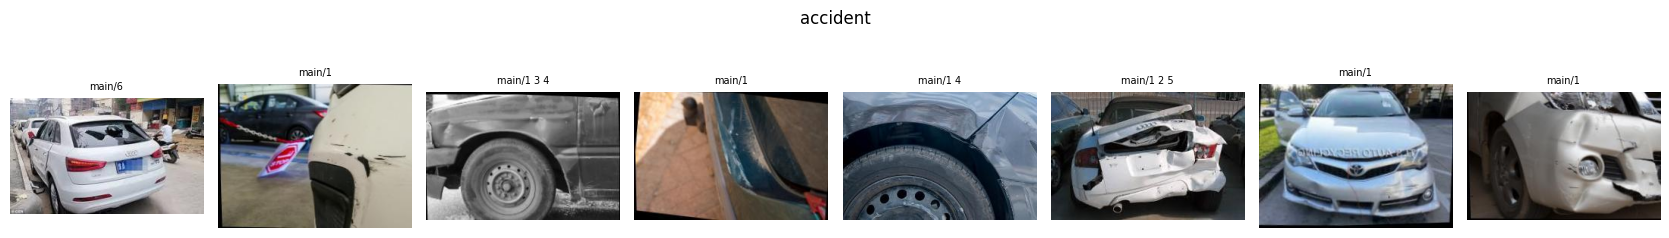

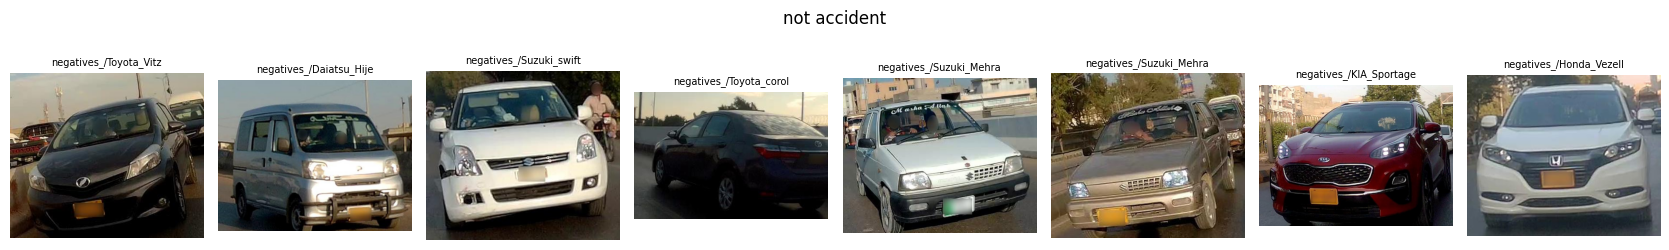

In [7]:
import matplotlib.pyplot as plt

def show_sample(rows, label, n=8):
    picks = [r for r in rows if r['label'] == label]
    if not picks:
        print('no images with label', label)
        return
    picks = random.Random(SEED).sample(picks, min(n, len(picks)))

    fig, axes = plt.subplots(1, len(picks), figsize=(2.1 * len(picks), 2.4))
    axes = np.atleast_1d(axes)
    for ax, row in zip(axes, picks):
        ax.imshow(Image.open(row['path']).convert('RGB'))
        ax.set_title(f"{row['dataset'].split(':')[0][:10]}/{row['source'][:12]}", fontsize=7)
        ax.axis('off')
    fig.suptitle('accident' if label else 'not accident', y=1.04)
    plt.tight_layout()
    plt.show()

show_sample(rows, 1)
show_sample(rows, 0)

In [ ]:
from transformers import AutoImageProcessor, CLIPVisionModelWithProjection


processor = AutoImageProcessor.from_pretrained(CLIP_MODEL)
clip = CLIPVisionModelWithProjection.from_pretrained(CLIP_MODEL).to(DEVICE).eval()

@torch.no_grad()
def encode(images):
    """PIL images -> L2-normalised embeddings. One place, used everywhere."""
    inputs = processor(images=images, return_tensors='pt').to(DEVICE)
    output = clip(pixel_values=inputs['pixel_values'])

    feats = getattr(output, 'image_embeds', None)
    if feats is None:                       
        feats = clip.visual_projection(output.last_hidden_state[:, 0])
    if not isinstance(feats, torch.Tensor):
        raise TypeError(f'expected a tensor, got {type(feats)}')

    return feats / feats.norm(dim=-1, keepdim=True)

EMBED_DIM = int(encode([Image.new('RGB', (224, 224))]).shape[1])
print('embedding dim', EMBED_DIM)

def embed_paths(paths, batch_size=BATCH_SIZE):
    out = []
    for start in range(0, len(paths), batch_size):
        chunk = paths[start : start + batch_size]
        images = [Image.open(path).convert('RGB') for path in chunk]
        out.append(encode(images).cpu().numpy())

        done = min(start + batch_size, len(paths))
        print(f'\r  embedded {done}/{len(paths)}', end='')
    print()
    return np.concatenate(out) if out else np.zeros((0, EMBED_DIM))

paths = [r['path'] for r in rows]
features = embed_paths(paths)

y = np.array([r['label'] for r in rows])
split = np.array([r['split'] for r in rows])

np.savez_compressed(ARTIFACTS / 'embeddings.npz', features=features, y=y, split=split)
print('features', features.shape)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

model.safetensors: downloading bytes:           |  0.00B            

[transformers] CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0

embedding dim 512
  embedded 11182/11182
features (11182, 512)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, average_precision_score,
                             classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score)

train = split == 'train'
valid = split == 'valid'
test  = split == 'test'

if valid.sum() == 0:           
    valid = test

print('train/valid/test:', train.sum(), valid.sum(), test.sum())

head = LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced')
head.fit(features[train], y[train])

val_scores = head.predict_proba(features[valid])[:, 1]
print('validation ROC AUC:', round(roc_auc_score(y[valid], val_scores), 4))
print('validation PR  AUC:', round(average_precision_score(y[valid], val_scores), 4))

train/valid/test: 8074 1967 1141
validation ROC AUC: 1.0
validation PR  AUC: 1.0


threshold          0.647
validation recall  0.997
validation precis. 1.000
=> roughly 1.0 alerts sent per real accident caught


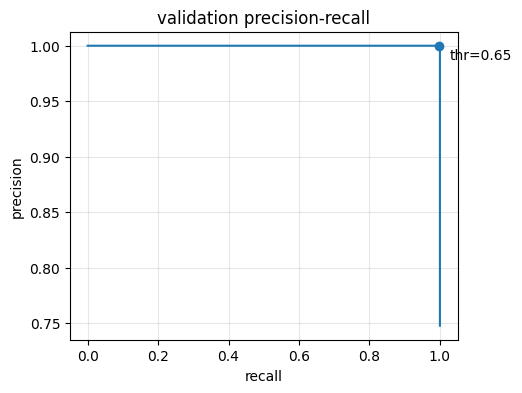

In [ ]:
precision, recall, thresholds = precision_recall_curve(y[valid], val_scores)

viable = [(p, r, t) for p, r, t in zip(precision[:-1], recall[:-1], thresholds) if r >= TARGET_RECALL]

if viable:
    best_precision, best_recall, THRESHOLD = max(viable, key=lambda item: item[0])
else:
    THRESHOLD = 0.5
    best_precision, best_recall = None, None
    print(f'WARNING: recall {TARGET_RECALL} is unreachable on validation; falling back to 0.5')

print(f'threshold          {THRESHOLD:.3f}')
if best_recall is not None:
    print(f'validation recall  {best_recall:.3f}')
    print(f'validation precis. {best_precision:.3f}')
    if best_precision > 0:
        print(f'=> roughly {1 / best_precision:.1f} alerts sent per real accident caught')

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(recall, precision)
if best_recall is not None:
    ax.scatter([best_recall], [best_precision], zorder=3)
    ax.annotate(f'thr={THRESHOLD:.2f}', (best_recall, best_precision),
                textcoords='offset points', xytext=(8, -10))
ax.set_xlabel('recall'); ax.set_ylabel('precision')
ax.set_title('validation precision-recall')
ax.grid(alpha=.3)
plt.show()

              precision    recall  f1-score   support

not accident      0.995     1.000     0.998       399
    accident      1.000     0.997     0.999       742

    accuracy                          0.998      1141
   macro avg      0.998     0.999     0.998      1141
weighted avg      0.998     0.998     0.998      1141



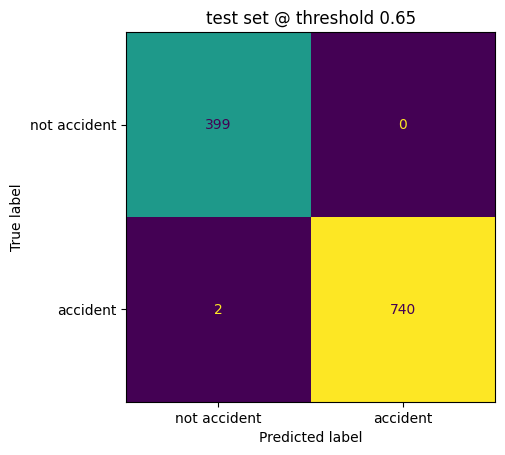

missed accidents (the costly error): 2
false alarms     (one SMS each)   : 0


In [11]:
test_scores = head.predict_proba(features[test])[:, 1]
test_pred = (test_scores >= THRESHOLD).astype(int)

print(classification_report(y[test], test_pred, target_names=['not accident', 'accident'], digits=3))

cm = confusion_matrix(y[test], test_pred)
ConfusionMatrixDisplay(cm, display_labels=['not accident', 'accident']).plot(colorbar=False)
plt.title(f'test set @ threshold {THRESHOLD:.2f}')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'missed accidents (the costly error): {fn}')
print(f'false alarms     (one SMS each)   : {fp}')

test_auc = roc_auc_score(y[test], test_scores)
if test_auc > 0.99:
    print()
    print(f'ROC AUC is {test_auc:.4f}. On a real vision task that is not a good')
    print('result, it is a warning. Something other than the concept is separating')
    print('the classes - usually the dataset each image came from. Section 9 on')
    print('your own photos is the only way to tell.')

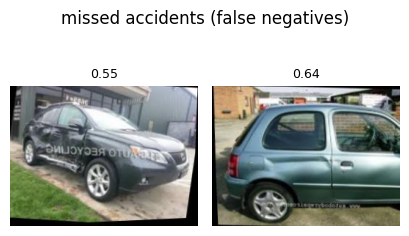

none — false alarms (false positives)


In [12]:
test_rows = [r for r, keep in zip(rows, test) if keep]

def show_errors(kind, n=8):
    if kind == 'fn':
        picked = [(r, s) for r, s, t, p in zip(test_rows, test_scores, y[test], test_pred) if t == 1 and p == 0]
        title = 'missed accidents (false negatives)'
    else:
        picked = [(r, s) for r, s, t, p in zip(test_rows, test_scores, y[test], test_pred) if t == 0 and p == 1]
        title = 'false alarms (false positives)'

    if not picked:
        print('none —', title)
        return

    picked = sorted(picked, key=lambda item: item[1])[:n] if kind == 'fn' else sorted(picked, key=lambda item: -item[1])[:n]
    fig, axes = plt.subplots(1, len(picked), figsize=(2.1 * len(picked), 2.4))
    axes = np.atleast_1d(axes)
    for ax, (row, score) in zip(axes, picked):
        ax.imshow(Image.open(row['path']).convert('RGB'))
        ax.set_title(f'{score:.2f}', fontsize=9)
        ax.axis('off')
    fig.suptitle(title, y=1.04)
    plt.tight_layout()
    plt.show()

show_errors('fn')
show_errors('fp')

In [13]:
reality_dir = Path(REALITY_CHECK_DIR)

if not reality_dir.exists():
    print(f'no {reality_dir} - skipping. Twenty of your own photos here is the single most')
    print('useful thing you can add to this notebook.')
else:
    check = (index_loose_folder(reality_dir / 'accident', 1, 'mine:accident')
             + index_loose_folder(reality_dir / 'normal', 0, 'mine:normal'))

    if not check:
        print(f'{reality_dir} exists but has no images in accident/ or normal/')
    else:
        check_features = embed_paths([r['path'] for r in check])
        check_scores = head.predict_proba(check_features)[:, 1]
        check_true = np.array([r['label'] for r in check])
        check_pred = (check_scores >= THRESHOLD).astype(int)

        print(classification_report(check_true, check_pred,
                                    target_names=['not accident', 'accident'],
                                    digits=3, zero_division=0))

        agreement = (check_pred == check_true).mean()
        print(f'agreement on your own photos: {agreement:.1%}  (test set was '
              f'{(test_pred == y[test]).mean():.1%})')

        if agreement < (test_pred == y[test]).mean() - 0.15:
            print('\nThe gap between these two numbers is the dataset bias, measured.')
            print('Fix it with data, not with a bigger model.')

        for row, score, pred in zip(check, check_scores, check_pred):
            mark = 'ok ' if pred == row['label'] else 'MISS'
            print(f"  {mark} {score:.2f}  {Path(row['path']).name}")

no data/reality_check - skipping. Twenty of your own photos here is the single most
useful thing you can add to this notebook.


In [14]:
artifact = {
    'task': 'accident-verification',
    'clip_model': CLIP_MODEL,
    'embedding_dim': int(features.shape[1]),
    'classes': ['not_accident', 'accident'],
    'weights': head.coef_[0].astype(float).tolist(),
    'bias': float(head.intercept_[0]),
    'threshold': float(THRESHOLD),
    'target_recall': TARGET_RECALL,
    'test_metrics': {
        'true_positives': int(tp), 'false_positives': int(fp),
        'true_negatives': int(tn), 'false_negatives': int(fn),
        'roc_auc': float(roc_auc_score(y[test], test_scores)),
        'pr_auc': float(average_precision_score(y[test], test_scores)),
    },
    'dataset': {'workspace': WORKSPACE, 'project': PROJECT, 'version': VERSION,
                'format': FORMAT, 'images': int(len(rows))},
}

out = ARTIFACTS / 'accident_head.json'
out.write_text(json.dumps(artifact, indent=2))
print('wrote', out, f'({out.stat().st_size / 1024:.1f} KB)')
print(json.dumps({k: v for k, v in artifact.items() if k != 'weights'}, indent=2))

wrote artifacts/accident_head.json (13.0 KB)
{
  "task": "accident-verification",
  "clip_model": "openai/clip-vit-base-patch32",
  "embedding_dim": 512,
  "classes": [
    "not_accident",
    "accident"
  ],
  "bias": 0.7905284925508785,
  "threshold": 0.6466099724683639,
  "target_recall": 0.95,
  "test_metrics": {
    "true_positives": 740,
    "false_positives": 0,
    "true_negatives": 399,
    "false_negatives": 2,
    "roc_auc": 1.0,
    "pr_auc": 1.0
  },
  "dataset": {
    "workspace": "sathwik-suresh-shetty",
    "project": "vehicle-accident-detection-1vdk8-gs41n",
    "version": 1,
    "format": "folder",
    "images": 11182
  }
}


/content/data/main/test/1/0015_JPEG_jpg.rf.5a1d16ef2587c4c36114ab99a16f12c5.jpg
{'is_accident': True, 'confidence': np.float64(0.9956), 'threshold': 0.6466099724683639}


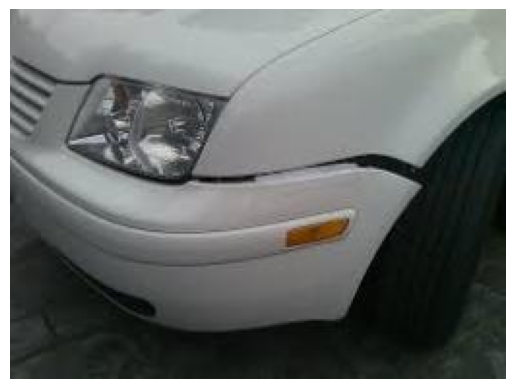

In [15]:
def load_head(path=ARTIFACTS / 'accident_head.json'):
    spec = json.loads(Path(path).read_text())
    return np.array(spec['weights']), spec['bias'], spec['threshold']

def predict_image(image_path):
    weights, bias, threshold = load_head()

    feats = encode([Image.open(image_path).convert('RGB')]).cpu().numpy()[0]

    logit = float(feats @ weights + bias)
    score = 1.0 / (1.0 + np.exp(-logit))

    return {'is_accident': bool(score >= threshold),
            'confidence': round(float(score), 4),
            'threshold': float(threshold)}

sample = next((r['path'] for r in rows if r['split'] == 'test' and r['label'] == 1), None)
if sample:
    print(sample)
    print(predict_image(sample))
    plt.imshow(Image.open(sample).convert('RGB')); plt.axis('off'); plt.show()

In [16]:
try:
    from google.colab import files
    files.download(str(ARTIFACTS / 'accident_head.json'))
except ImportError:
    print('not on Colab — copy', (ARTIFACTS / 'accident_head.json').resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## What this model does not solve

**It only sees vehicles.** The positive class is a damaged vehicle or a crash scene, so a
pedestrian struck by a car that drove off, a fall, or any medical emergency without a
vehicle in frame will score low. That is a scope limit, not a bug to tune away. The
emergency page must therefore offer a second path — "can't get a clear photo?" — that
alerts the contact anyway and marks the report `unverified`. The contact still decides,
so nobody is left unreachable because a classifier saw no bumper.

**Spoofing.** Someone can save an accident photo from the web and upload it. No classifier
catches that, because the image genuinely is an accident. That is handled elsewhere: EXIF
timestamp and GPS freshness, browser geolocation at scan time, rate limits per QR token, and
ultimately the emergency contact who knows whether the person is at work or on the road.

**Domain shift.** If the sampled images in section 4 looked like dashcam frames, the test
numbers above are optimistic. The honest check is a dozen phone photos of your own — staged
in a car park is fine — scored with `predict_image`. If those fail while the test set passes,
the dataset is the problem.

**Severity.** The head answers one binary question. Whether to describe an accident as minor
or serious needs either a second label set or a vision-language model, and that text is what
would make the alert to the emergency contact genuinely useful.